In [38]:
# ======================================
# CARGA Y EXPLORACIÓN INICIAL DEL DATASET
# ======================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [39]:
df = pd.read_csv("../data/2018_presidencia_primera_vuelta.dta.csv")

In [40]:
df.head()

,id_electoral,ano,tipo_eleccion,fecha_eleccion,coddpto,departamento,codmpio,municipio,circunscripcion,codigo_partido,codigo_lista,primer_apellido,segundo_apellido,nombres,votos,curules
0,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180003.0,1,PETRO,URREGO,GUSTAVO FRANCISCO,77067,1
1,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180004.0,2,NaN,NaN,PROMOTORES VOTO EN BLANCO,1847,0
2,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20130001.0,3,DUQUE,MARQUEZ,IVAN,535239,1
3,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180002.0,4,DE LA CALLE,LOMBANA,HUMBERTO,25896,0
4,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20170002.0,5,TRUJILLO,SARMIENTO,JORGE ANTONIO,2197,0


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12725 entries, 0 to 12724
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_electoral      12725 non-null  int64  
 1   ano               12725 non-null  int64  
 2   tipo_eleccion     12725 non-null  str    
 3   fecha_eleccion    12725 non-null  str    
 4   coddpto           12725 non-null  int64  
 5   departamento      12725 non-null  str    
 6   codmpio           12725 non-null  int64  
 7   municipio         12725 non-null  str    
 8   circunscripcion   12725 non-null  str    
 9   codigo_partido    9284 non-null   float64
 10  codigo_lista      12725 non-null  int64  
 11  primer_apellido   11629 non-null  str    
 12  segundo_apellido  8188 non-null   str    
 13  nombres           9284 non-null   str    
 14  votos             12725 non-null  int64  
 15  curules           12725 non-null  int64  
dtypes: float64(1), int64(7), str(8)
memory usage: 1.6 M

In [42]:
df.describe()

,id_electoral,ano,coddpto,codmpio,codigo_partido,codigo_lista,votos,curules
count,12725.0,12725.0,12725.000000,12725.000000,9.284000e+03,12725.000000,1.272500e+04,12725.000000
mean,120180001.0,2018.0,36.755678,37188.619411,2.017238e+07,273.159450,1.543709e+03,0.187112
std,0.0,0.0,26.401656,26386.350831,1.656939e+04,441.312562,1.935942e+04,0.390017
min,120180001.0,2018.0,5.000000,5001.000000,2.013000e+07,1.000000,1.000000e+00,0.000000
25%,120180001.0,2018.0,15.000000,15401.000000,2.018000e+07,3.000000,1.600000e+01,0.000000
50%,120180001.0,2018.0,25.000000,25612.000000,2.018000e+07,6.000000,7.300000e+01,0.000000
75%,120180001.0,2018.0,63.000000,63272.000000,2.018000e+07,997.000000,4.690000e+02,0.000000
max,120180001.0,2018.0,99.000000,99773.000000,2.018001e+07,999.000000,1.244477e+06,1.000000


In [43]:
df.isnull().sum()

id_electoral           0
ano                    0
tipo_eleccion          0
fecha_eleccion         0
coddpto                0
departamento           0
codmpio                0
municipio              0
circunscripcion        0
codigo_partido      3441
codigo_lista           0
primer_apellido     1096
segundo_apellido    4537
nombres             3441
votos                  0
curules                0
dtype: int64

In [44]:
df.columns

Index(['id_electoral', 'ano', 'tipo_eleccion', 'fecha_eleccion', 'coddpto',
       'departamento', 'codmpio', 'municipio', 'circunscripcion',
       'codigo_partido', 'codigo_lista', 'primer_apellido', 'segundo_apellido',
       'nombres', 'votos', 'curules'],
      dtype='str')

In [45]:
# ======================================
# TOTAL DE VOTOS POR CANDIDATO
# ======================================

df["candidato"] = (
    df["nombres"].fillna("") + " " +
    df["primer_apellido"].fillna("") + " " +
    df["segundo_apellido"].fillna("") + " "
).str.strip()

df[["candidato"]].head(10)

,candidato
0,GUSTAVO FRANCISCO PETRO URREGO
1,PROMOTORES VOTO EN BLANCO
2,IVAN DUQUE MARQUEZ
3,HUMBERTO DE LA CALLE LOMBANA
4,JORGE ANTONIO TRUJILLO SARMIENTO
5,SERGIO FAJARDO VALDERRAMA
6,VIVIANE ALEIDA MORALES HOYOS
7,GERMAN VARGAS LLERAS
8,TARJETAS NO MARCADAS
9,VOTOS NULOS


In [46]:


votes_by_candidate = (
    df.groupby("candidato")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_candidate

candidato
IVAN DUQUE MARQUEZ                  7617114
GUSTAVO FRANCISCO PETRO URREGO      4854831
SERGIO FAJARDO VALDERRAMA           4602916
GERMAN VARGAS LLERAS                1412392
HUMBERTO DE LA CALLE LOMBANA         396151
VOTOS EN BLANCO                      338581
VOTOS NULOS                          242002
JORGE ANTONIO TRUJILLO SARMIENTO      65767
TARJETAS NO MARCADAS                  47675
VIVIANE ALEIDA MORALES HOYOS          36138
PROMOTORES VOTO EN BLANCO             30128
Name: votos, dtype: int64

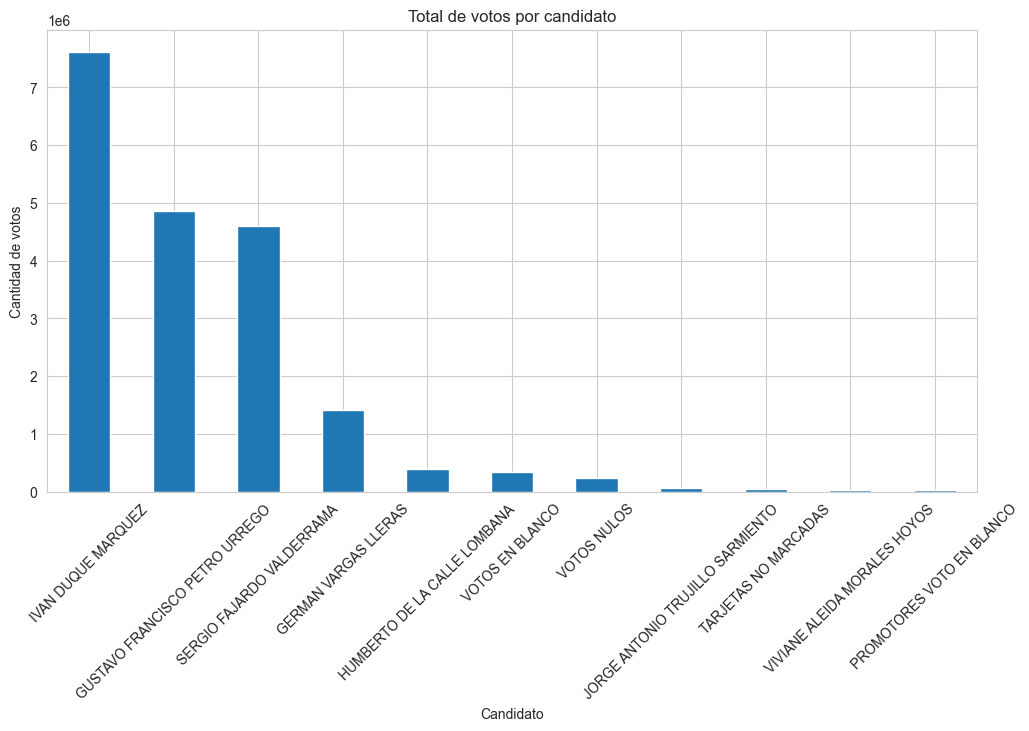

In [47]:
plt.figure(figsize=(12,6))

votes_by_candidate.plot(kind="bar")

plt.title("Total de votos por candidato")
plt.xlabel("Candidato")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

In [48]:
votes_by_department = (
    df.groupby("departamento")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_department

departamento
BOGOTA DC                                                  3705960
ANTIOQUIA                                                  2615238
VALLE DEL CAUCA                                            1780994
CUNDINAMARCA                                               1208999
SANTANDER                                                  1004596
ATLANTICO                                                   873397
BOLIVAR                                                     638517
NORTE DE SANTANDER                                          626915
CORDOBA                                                     597614
TOLIMA                                                      584488
BOYACA                                                      561691
NARINO                                                      525215
CAUCA                                                       482000
HUILA                                                       456879
CALDAS                                           

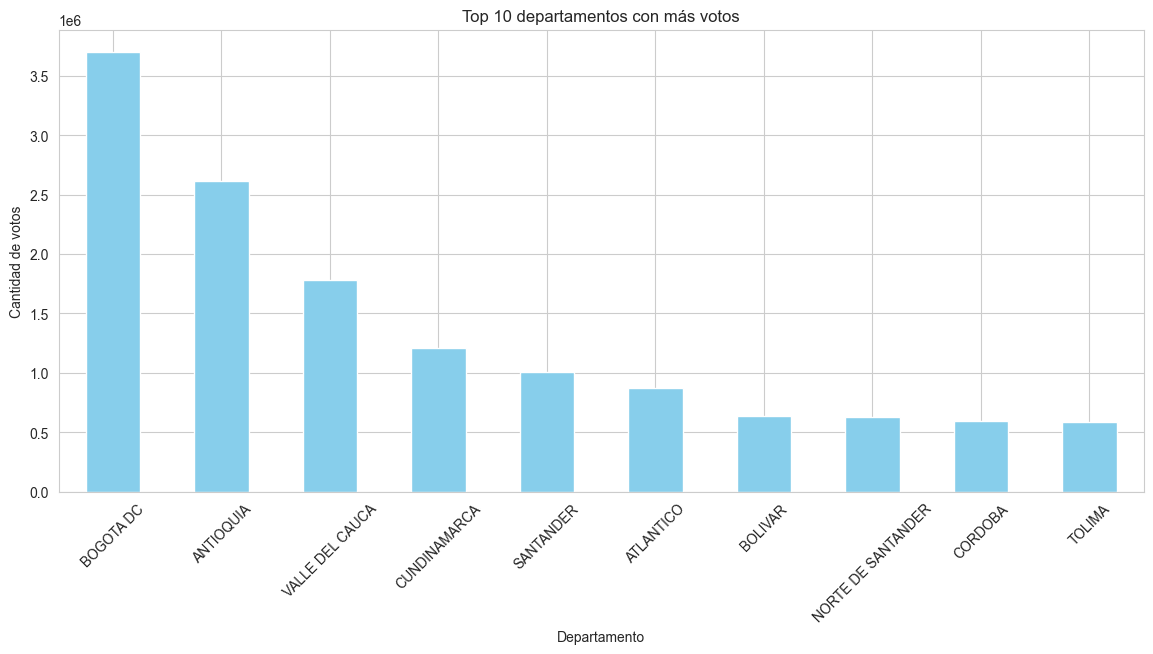

In [49]:
plt.figure(figsize=(14,6))

votes_by_department.head(10).plot(kind="bar", color="skyblue")

plt.title("Top 10 departamentos con más votos")
plt.xlabel("Departamento")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

In [50]:
votes_candidate_department = (
    df.groupby(["departamento", "candidato"])["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_candidate_department

departamento                                             candidato                     
ANTIOQUIA                                                IVAN DUQUE MARQUEZ                1375965
BOGOTA DC                                                SERGIO FAJARDO VALDERRAMA         1244477
                                                         GUSTAVO FRANCISCO PETRO URREGO    1099955
                                                         IVAN DUQUE MARQUEZ                 989744
ANTIOQUIA                                                SERGIO FAJARDO VALDERRAMA          732993
                                                                                            ...   
AMAZONAS                                                 PROMOTORES VOTO EN BLANCO              20
ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA  PROMOTORES VOTO EN BLANCO              18
                                                         TARJETAS NO MARCADAS                   15
GUAINIA              

In [51]:
winner_by_department = (
    df.groupby(["departamento", "candidato"])["votos"]
    .sum()
    .reset_index()
)
winner_by_department.head()

,departamento,candidato,votos
0,AMAZONAS,GERMAN VARGAS LLERAS,1308
1,AMAZONAS,GUSTAVO FRANCISCO PETRO URREGO,5931
2,AMAZONAS,HUMBERTO DE LA CALLE LOMBANA,739
3,AMAZONAS,IVAN DUQUE MARQUEZ,7104
4,AMAZONAS,JORGE ANTONIO TRUJILLO SARMIENTO,87


In [52]:
winner_by_department = (
    winner_by_department
    .sort_values("votos", ascending=False)
)

In [53]:
winners = winner_by_department.drop_duplicates(
    subset="departamento",
    keep="first"
)

winners

,departamento,candidato,votos
14,ANTIOQUIA,IVAN DUQUE MARQUEZ,1375965
61,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477
344,VALLE DEL CAUCA,IVAN DUQUE MARQUEZ,527622
179,CUNDINAMARCA,IVAN DUQUE MARQUEZ,479936
311,SANTANDER,IVAN DUQUE MARQUEZ,442219
267,NORTE DE SANTANDER,IVAN DUQUE MARQUEZ,378192
45,ATLANTICO,GUSTAVO FRANCISCO PETRO URREGO,331979
333,TOLIMA,IVAN DUQUE MARQUEZ,285470
69,BOLIVAR,IVAN DUQUE MARQUEZ,258540
166,CORDOBA,GUSTAVO FRANCISCO PETRO URREGO,250437


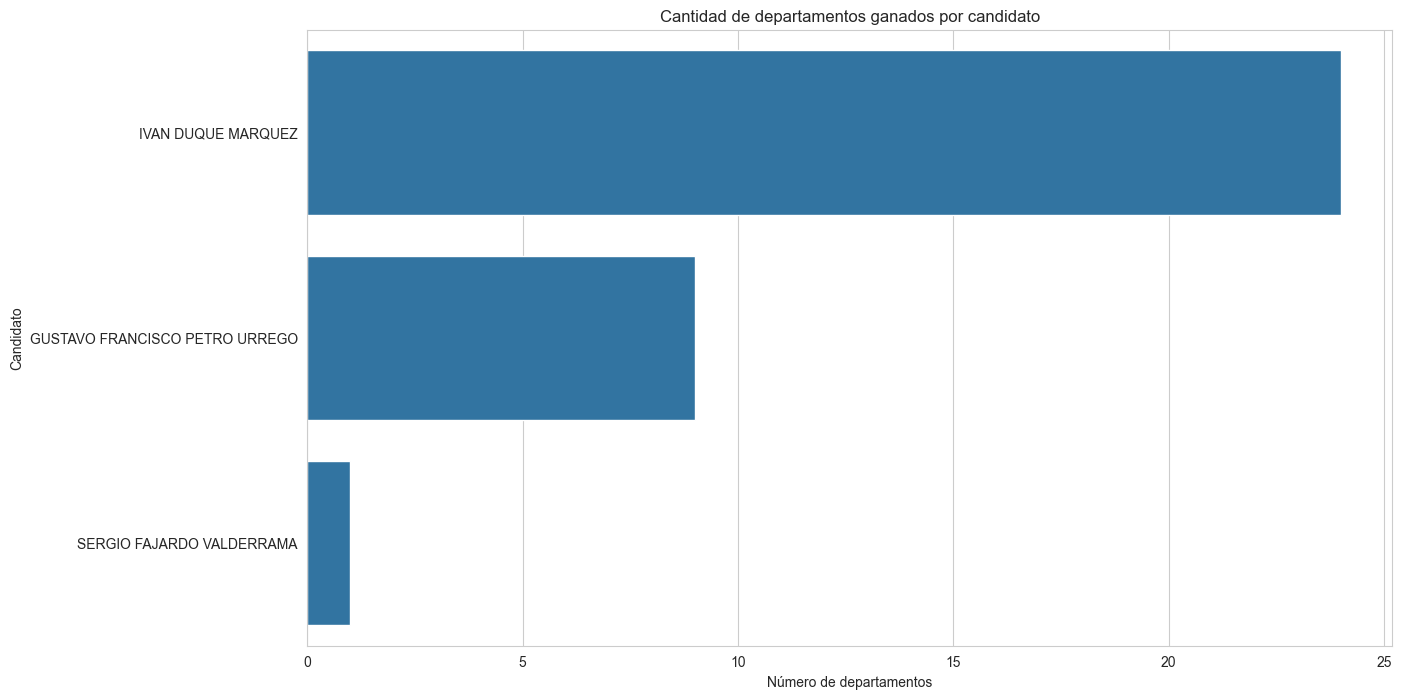

In [54]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=winners,
    y="candidato",
    order=winners["candidato"].value_counts().index
)

plt.title("Cantidad de departamentos ganados por candidato")
plt.xlabel("Número de departamentos")
plt.ylabel("Candidato")

plt.show()

In [55]:
winners[winners["candidato"] == "SERGIO FAJARDO VALDERRAMA"]

,departamento,candidato,votos
61,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477


In [56]:
winners[winners["candidato"] == "IVAN DUQUE MARQUEZ"]

,departamento,candidato,votos
14,ANTIOQUIA,IVAN DUQUE MARQUEZ,1375965
344,VALLE DEL CAUCA,IVAN DUQUE MARQUEZ,527622
179,CUNDINAMARCA,IVAN DUQUE MARQUEZ,479936
311,SANTANDER,IVAN DUQUE MARQUEZ,442219
267,NORTE DE SANTANDER,IVAN DUQUE MARQUEZ,378192
333,TOLIMA,IVAN DUQUE MARQUEZ,285470
69,BOLIVAR,IVAN DUQUE MARQUEZ,258540
212,HUILA,IVAN DUQUE MARQUEZ,241612
80,BOYACA,IVAN DUQUE MARQUEZ,227676
245,META,IVAN DUQUE MARQUEZ,212158


In [58]:
winners[winners["candidato"] == "GUSTAVO FRANCISCO PETRO URREGO"]

,departamento,candidato,votos
45,ATLANTICO,GUSTAVO FRANCISCO PETRO URREGO,331979
166,CORDOBA,GUSTAVO FRANCISCO PETRO URREGO,250437
254,NARINO,GUSTAVO FRANCISCO PETRO URREGO,239124
122,CAUCA,GUSTAVO FRANCISCO PETRO URREGO,231470
320,SUCRE,GUSTAVO FRANCISCO PETRO URREGO,154801
221,LA GUAJIRA,GUSTAVO FRANCISCO PETRO URREGO,85523
276,PUTUMAYO,GUSTAVO FRANCISCO PETRO URREGO,60683
144,CHOCO,GUSTAVO FRANCISCO PETRO URREGO,49966
353,VAUPES,GUSTAVO FRANCISCO PETRO URREGO,2514


In [59]:
votes_by_city = (
    df.groupby("municipio")["votos"]
    .sum()
    .sort_values(ascending=False)
)

votes_by_city.head(10)

municipio
BOGOTA DC              3705960
MEDELLIN               1009878
CALI                    883217
BARRANQUILLA            501970
SAN JOSE DE CUCUTA      320722
BUCARAMANGA             306948
CARTAGENA DE INDIAS     304264
IBAGUE                  255315
PEREIRA                 234395
VILLAVICENCIO           225253
Name: votos, dtype: int64

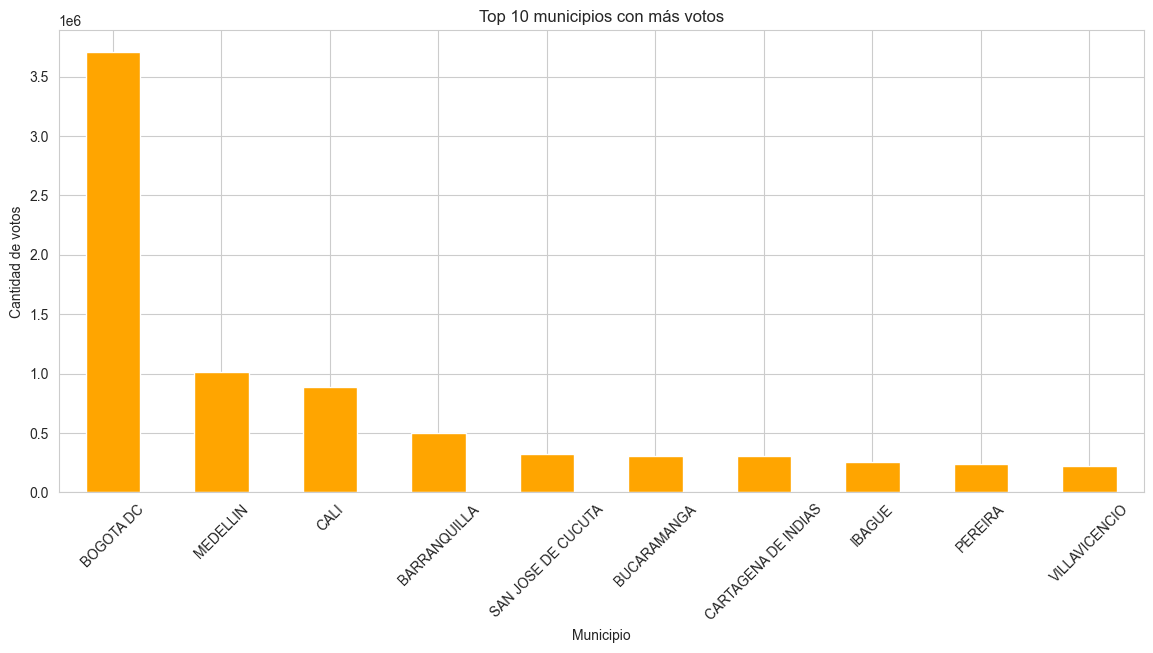

In [60]:
plt.figure(figsize=(14,6))

votes_by_city.head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 municipios con más votos")
plt.xlabel("Municipio")
plt.ylabel("Cantidad de votos")

plt.xticks(rotation=45)

plt.show()

In [65]:
top_cities = [
    "BOGOTA DC",
    "MEDELLIN",
    "CALI",
    "BARRANQUILLA",
    "SAN JOSE DE CUCUTA"
]

top_cities_df = df[df["municipio"].isin(top_cities)]

top_cities_df.head()

,id_electoral,ano,tipo_eleccion,fecha_eleccion,coddpto,departamento,codmpio,municipio,circunscripcion,codigo_partido,codigo_lista,primer_apellido,segundo_apellido,nombres,votos,curules,candidato
0,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180003.0,1,PETRO,URREGO,GUSTAVO FRANCISCO,77067,1,GUSTAVO FRANCISCO PETRO URREGO
1,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180004.0,2,NaN,NaN,PROMOTORES VOTO EN BLANCO,1847,0,PROMOTORES VOTO EN BLANCO
2,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20130001.0,3,DUQUE,MARQUEZ,IVAN,535239,1,IVAN DUQUE MARQUEZ
3,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20180002.0,4,DE LA CALLE,LOMBANA,HUMBERTO,25896,0,HUMBERTO DE LA CALLE LOMBANA
4,120180001,2018,Presidencia,Mayo 27,5,ANTIOQUIA,5001,MEDELLIN,Nacional,20170002.0,5,TRUJILLO,SARMIENTO,JORGE ANTONIO,2197,0,JORGE ANTONIO TRUJILLO SARMIENTO


In [68]:
city_winners = (
    top_cities_df
    .groupby(["municipio", "candidato"])["votos"]
    .sum()
    .reset_index()
)

city_winners.head()

,municipio,candidato,votos
0,BARRANQUILLA,GERMAN VARGAS LLERAS,79653
1,BARRANQUILLA,GUSTAVO FRANCISCO PETRO URREGO,188185
2,BARRANQUILLA,HUMBERTO DE LA CALLE LOMBANA,8635
3,BARRANQUILLA,IVAN DUQUE MARQUEZ,144321
4,BARRANQUILLA,JORGE ANTONIO TRUJILLO SARMIENTO,1958


In [69]:
city_winners = city_winners.sort_values(
    "votos",
    ascending=False
)

city_winners = city_winners.drop_duplicates(
    subset="municipio",
    keep="first"
)

city_winners

,municipio,candidato,votos
17,BOGOTA DC,SERGIO FAJARDO VALDERRAMA,1244477
36,MEDELLIN,IVAN DUQUE MARQUEZ,535239
28,CALI,SERGIO FAJARDO VALDERRAMA,284347
47,SAN JOSE DE CUCUTA,IVAN DUQUE MARQUEZ,191221
1,BARRANQUILLA,GUSTAVO FRANCISCO PETRO URREGO,188185
